In [83]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
# Load and preprocess data
df = pd.read_csv('data/synthetic_data.csv')  # Download from Kaggle

# Insert the check here to shuffle and randomize labels
df_shuffled = df.sample(frac=1, random_state=42)
df_shuffled['Health_Issues'] = np.random.randint(0, 4, len(df_shuffled))
X = df_shuffled.drop(['Health_Issues', 'ID'], axis=1)
y = df_shuffled['Health_Issues']

X = df.drop(['ID', 'Health_Issues'], axis=1)
y = df['Health_Issues']

# Label encode target
le_y = LabelEncoder()
y = le_y.fit_transform(y)

In [85]:
# Categorical columns from document
cat_cols = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation', 'Smoking', 'Alcohol_Consumption']
num_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours']

# One-hot encode categoricals
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(ohe.fit_transform(X[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))
X_num = X[num_cols]
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

In [86]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=0.2, random_state=42)

# For pruning, create validation set from train
X_train_prune, X_val, y_train_prune, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [87]:
class MyDecisionTree:
    def __init__(self, max_depth=5, min_samples=2):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.feature_importance = None
        self.tree = None
        self.n_total = None

    def gini(self, y):
        if len(y) == 0:
            return 0
        p = np.bincount(y) / len(y)
        return 1 - np.sum(p ** 2)

    def best_split(self, X, y):
        n = len(y)
        if n <= 1:
            return None, None, self.gini(y)
        parent_gini = self.gini(y)
        best_weighted_gini = float('inf')
        best_feature = None
        best_threshold = None
        for feature in range(X.shape[1]):
            values = X[:, feature]
            sorted_idx = np.argsort(values)
            for i in range(1, n):
                if values[sorted_idx[i-1]] == values[sorted_idx[i]]:
                    continue
                threshold = (values[sorted_idx[i-1]] + values[sorted_idx[i]]) / 2
                left = y[sorted_idx[:i]]
                right = y[sorted_idx[i:]]
                if len(left) == 0 or len(right) == 0:
                    continue
                weighted_gini = (len(left) / n) * self.gini(left) + (len(right) / n) * self.gini(right)
                if weighted_gini < best_weighted_gini:
                    best_weighted_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold, best_weighted_gini

    def build_tree(self, X, y, depth=0):
        n = len(y)
        # FIX: support max_depth=None (unlimited depth)
        if ((self.max_depth is not None and depth >= self.max_depth)
            or n < self.min_samples or len(np.unique(y)) == 1):
            majority = int(np.argmax(np.bincount(y)))
            return {'leaf': True, 'class': majority}
        feature, threshold, weighted_gini = self.best_split(X, y)
        if feature is None:
            majority = int(np.argmax(np.bincount(y)))
            return {'leaf': True, 'class': majority}
        gini_parent = self.gini(y)
        gain = gini_parent - weighted_gini
        self.feature_importance[feature] += gain * (n / self.n_total)
        left_idx = X[:, feature] <= threshold
        right_idx = ~left_idx
        left_subtree = self.build_tree(X[left_idx], y[left_idx], depth + 1)
        right_subtree = self.build_tree(X[right_idx], y[right_idx], depth + 1)
        return {'leaf': False, 'feature': feature, 'threshold': threshold,
                'left': left_subtree, 'right': right_subtree, 'class': int(np.argmax(np.bincount(y)))}

    def fit(self, X, y):
        # Ensure numpy arrays so that slicing X[:, feature] works with pandas inputs
        X = np.asarray(X)
        y = np.asarray(y, dtype=int)
        self.n_total = len(y)
        self.feature_importance = np.zeros(X.shape[1])
        self.tree = self.build_tree(X, y)
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)
        return self

    def predict_one(self, x, node):
        if node['leaf']:
            return node['class']
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        # Accept pandas DataFrame by converting to numpy
        X = np.asarray(X)
        return np.array([self.predict_one(x, self.tree) for x in X])

    # scikit-learn compatibility: allow cloning in cross_val_score
    def get_params(self, deep=True):
        return {'max_depth': self.max_depth, 'min_samples': self.min_samples}

    def set_params(self, **params):
        for key, val in params.items():
            setattr(self, key, val)
        return self

    # NEW: sklearn requires score() if no scoring is provided (used by permutation_importance)
    def score(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        y_pred = self.predict(X)
        return float(np.mean(y_pred == y))

    # Pruning methods
    def count_leaves(self, node):
        if node['leaf']:
            return 1
        return self.count_leaves(node['left']) + self.count_leaves(node['right'])

    def calculate_error(self, X, y, node):
        y_pred = np.array([self.predict_one(xi, node) for xi in np.asarray(X)])
        return np.mean(y_pred != y)

    def prune_tree(self, node, alpha, validation_X, validation_y):
        if node['leaf']:
            return self.calculate_error(validation_X, validation_y, node)
        left_error = self.prune_tree(node['left'], alpha, validation_X, validation_y)
        right_error = self.prune_tree(node['right'], alpha, validation_X, validation_y)
        subtree_error = left_error + right_error
        leaf_node = {'leaf': True, 'class': node.get('class', 0)}
        leaf_error = self.calculate_error(validation_X, validation_y, leaf_node)
        num_leaves_subtree = self.count_leaves(node)
        if leaf_error + alpha <= subtree_error + alpha * (num_leaves_subtree - 1):
            # replace subtree with leaf
            node.clear()
            node['leaf'] = True
            node['class'] = leaf_node['class']
            return leaf_error + alpha
        return subtree_error + alpha * num_leaves_subtree

Custom DT - Accuracy: 0.9975 F1: 0.9957810563253527 MCC: 0.9950773810083864
Confusion Matrix:
 [[ 693    1    0    0]
 [   1   82    0    0]
 [   0    0    5    0]
 [   3    0    0 1215]]


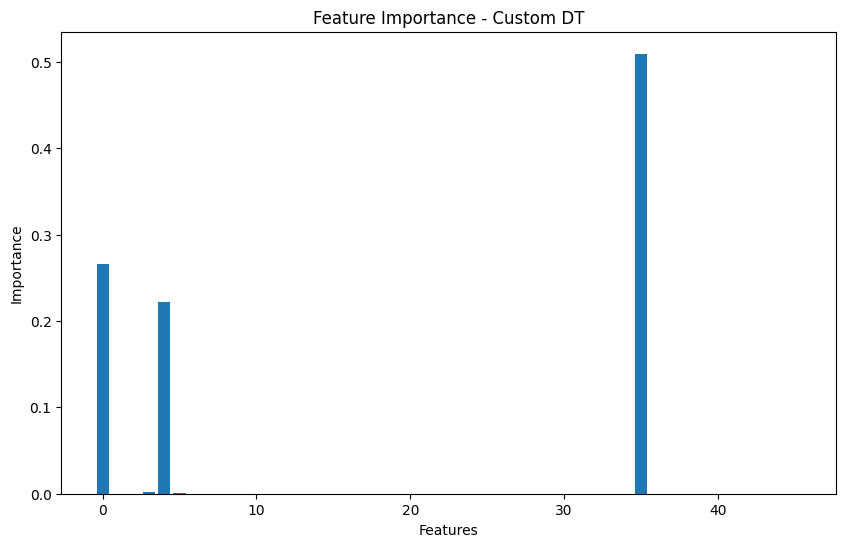

In [88]:
# a) Custom Decision Tree with Gini
my_tree = MyDecisionTree(max_depth=5, min_samples=2)
my_tree.fit(X_train, y_train)
y_pred_my = my_tree.predict(X_test)
acc_my = accuracy_score(y_test, y_pred_my)
f1_my = f1_score(y_test, y_pred_my, average='macro')
cm_my = confusion_matrix(y_test, y_pred_my)
mcc_my = matthews_corrcoef(y_test, y_pred_my)
print("Custom DT - Accuracy:", acc_my, "F1:", f1_my, "MCC:", mcc_my)
print("Confusion Matrix:\n", cm_my)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(my_tree.feature_importance)), my_tree.feature_importance)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance - Custom DT')
plt.show()

In [89]:
# b) Pruning
# Tune alpha via cross-validation (simple grid search)
alphas = np.logspace(-4, 0, 5)
best_alpha = 0
best_score = 0
for alpha in alphas:
    tree_temp = MyDecisionTree(max_depth=None)  # Full tree for pruning
    tree_temp.fit(X_train_prune, y_train_prune)
    tree_temp.prune_tree(tree_temp.tree, alpha, X_val, y_val)
    score = accuracy_score(y_val, tree_temp.predict(X_val))
    if score > best_score:
        best_score = score
        best_alpha = alpha

In [90]:
# Prune final tree
my_tree_pruned = MyDecisionTree(max_depth=None)
my_tree_pruned.fit(X_train, y_train)
my_tree_pruned.prune_tree(my_tree_pruned.tree, best_alpha, X_val, y_val)
# Recompute importance on pruned tree (refit to update)
my_tree_pruned.fit(X_train, y_train)  # Note: Importance is recomputed during fit, but pruning modifies tree
y_pred_pruned = my_tree_pruned.predict(X_test)
acc_pruned = accuracy_score(y_test, y_pred_pruned)
f1_pruned = f1_score(y_test, y_pred_pruned, average='macro')
cm_pruned = confusion_matrix(y_test, y_pred_pruned)
mcc_pruned = matthews_corrcoef(y_test, y_pred_pruned)
print("Pruned DT - Accuracy:", acc_pruned, "F1:", f1_pruned, "MCC:", mcc_pruned)
print("Confusion Matrix:\n", cm_pruned)

Pruned DT - Accuracy: 0.9975 F1: 0.9957810563253527 MCC: 0.9950773810083864
Confusion Matrix:
 [[ 693    1    0    0]
 [   1   82    0    0]
 [   0    0    5    0]
 [   3    0    0 1215]]


In [91]:
# c) Comparison with sklearn DT and RF
dt_sk = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=2, random_state=42)
dt_sk.fit(X_train, y_train)
y_pred_sk = dt_sk.predict(X_test)
acc_sk = accuracy_score(y_test, y_pred_sk)
f1_sk = f1_score(y_test, y_pred_sk, average='macro')
cm_sk = confusion_matrix(y_test, y_pred_sk)
mcc_sk = matthews_corrcoef(y_test, y_pred_sk)
print("sklearn DT - Accuracy:", acc_sk, "F1:", f1_sk, "MCC:", mcc_sk)
print("Confusion Matrix:\n", cm_sk)

sklearn DT - Accuracy: 0.9975 F1: 0.9957810563253527 MCC: 0.9950773810083864
Confusion Matrix:
 [[ 693    1    0    0]
 [   1   82    0    0]
 [   0    0    5    0]
 [   3    0    0 1215]]


In [92]:
rf = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
cm_rf = confusion_matrix(y_test, y_pred_rf)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
print("RF - Accuracy:", acc_rf, "F1:", f1_rf, "MCC:", mcc_rf)
print("Confusion Matrix:\n", cm_rf)

RF - Accuracy: 0.9925 F1: 0.729606161349214 MCC: 0.9851879545577897
Confusion Matrix:
 [[ 692    0    0    2]
 [   7   76    0    0]
 [   0    5    0    0]
 [   1    0    0 1217]]


In [93]:
# Cross-validation (5-fold) for all models
cv_scores_my = cross_val_score(MyDecisionTree(max_depth=5, min_samples=2), X, y, cv=5, scoring='accuracy')
cv_scores_sk = cross_val_score(dt_sk, X, y, cv=5, scoring='accuracy')
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("CV Accuracy - Custom DT:", cv_scores_my.mean(), "sklearn DT:", cv_scores_sk.mean(), "RF:", cv_scores_rf.mean())

CV Accuracy - Custom DT: 0.9984000000000002 sklearn DT: 0.9983000000000001 RF: 0.9951000000000001


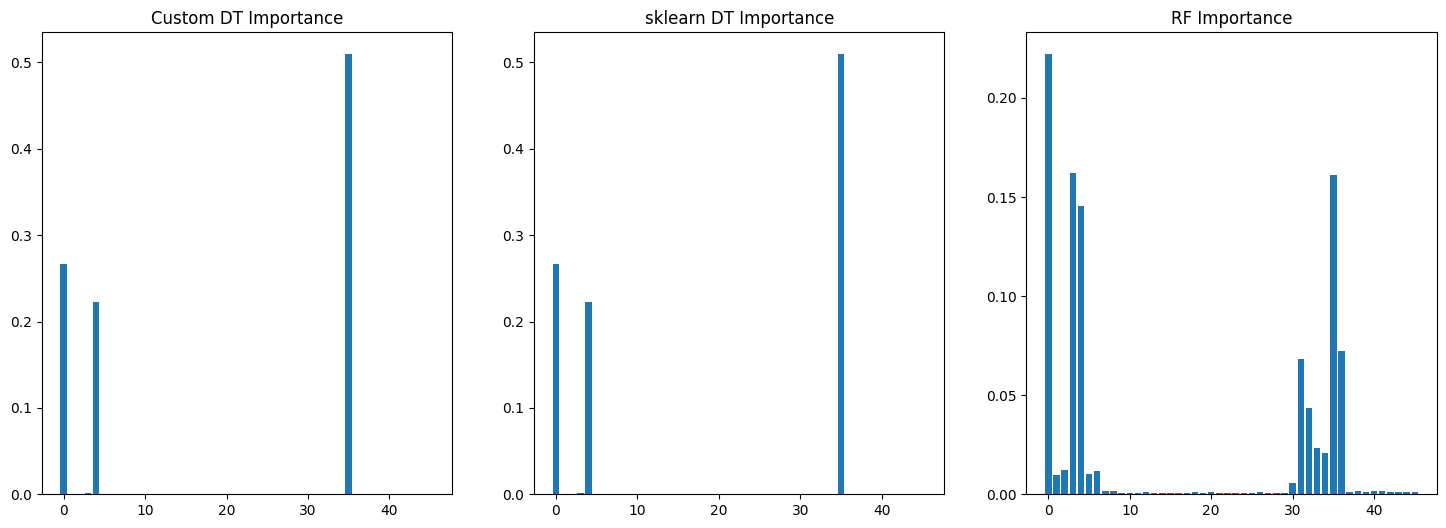

In [94]:
# Visualize importance comparison
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].bar(range(len(my_tree.feature_importance)), my_tree.feature_importance)
ax[0].set_title('Custom DT Importance')
ax[1].bar(range(len(dt_sk.feature_importances_)), dt_sk.feature_importances_)
ax[1].set_title('sklearn DT Importance')
ax[2].bar(range(len(rf.feature_importances_)), rf.feature_importances_)
ax[2].set_title('RF Importance')
plt.show()

In [95]:
# d) Feature Engineering and Selection
# Engineering: Interactions, binning, normalization
X_eng = X.copy()
X_eng['Coffee_Sleep_Interaction'] = X_eng['Coffee_Intake'] * X_eng['Sleep_Hours']
X_eng['Age_Binned'] = pd.cut(X_eng['Age'], bins=[18, 30, 50, 80], labels=['Young', 'Middle', 'Old'])
X_eng = pd.get_dummies(X_eng, columns=['Age_Binned'])

# Normalize numerical
scaler = StandardScaler()
X_eng[num_cols + ['Coffee_Sleep_Interaction']] = scaler.fit_transform(X_eng[num_cols + ['Coffee_Sleep_Interaction']])

# Remove high-correlation features (example: if corr > 0.8)
corr_matrix = X_eng.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
X_eng = X_eng.drop(to_drop, axis=1)

# Split again
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_eng.values, y, test_size=0.2, random_state=42)

In [96]:
# Feature selection using custom tree importance
tree_select = MyDecisionTree()
tree_select.fit(X_train_eng, y_train_eng)
importances = tree_select.feature_importance
threshold = 0.01
selected_idx = np.where(importances > threshold)[0]
if len(selected_idx) == 0:
    selected_idx = np.argsort(importances)[-10:]  # Top-10 if none above threshold
X_train_sel = X_train_eng[:, selected_idx]
X_test_sel = X_test_eng[:, selected_idx]

In [97]:
# Retrain models on selected features
my_tree_sel = MyDecisionTree(max_depth=5, min_samples=2)
my_tree_sel.fit(X_train_sel, y_train_eng)
y_pred_sel = my_tree_sel.predict(X_test_sel)
acc_sel = accuracy_score(y_test_eng, y_pred_sel)
f1_sel = f1_score(y_test_eng, y_pred_sel, average='macro')
print("Custom DT on Selected Features - Accuracy:", acc_sel, "F1:", f1_sel)

Custom DT on Selected Features - Accuracy: 0.996 F1: 0.994934393882244


Permutation Importance: [0.1696 0.1129 0.4045]


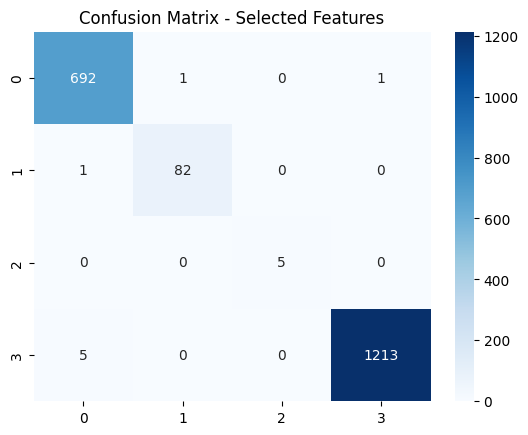

In [98]:
# Permutation importance
perm_imp = permutation_importance(my_tree_sel, X_test_sel, y_test_eng)
print("Permutation Importance:", perm_imp['importances_mean'])

# Visualize confusion matrix for selected
sns.heatmap(confusion_matrix(y_test_eng, y_pred_sel), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Selected Features')
plt.show()

## Visualizations: Decision Tree (sklearn) and Random Forest

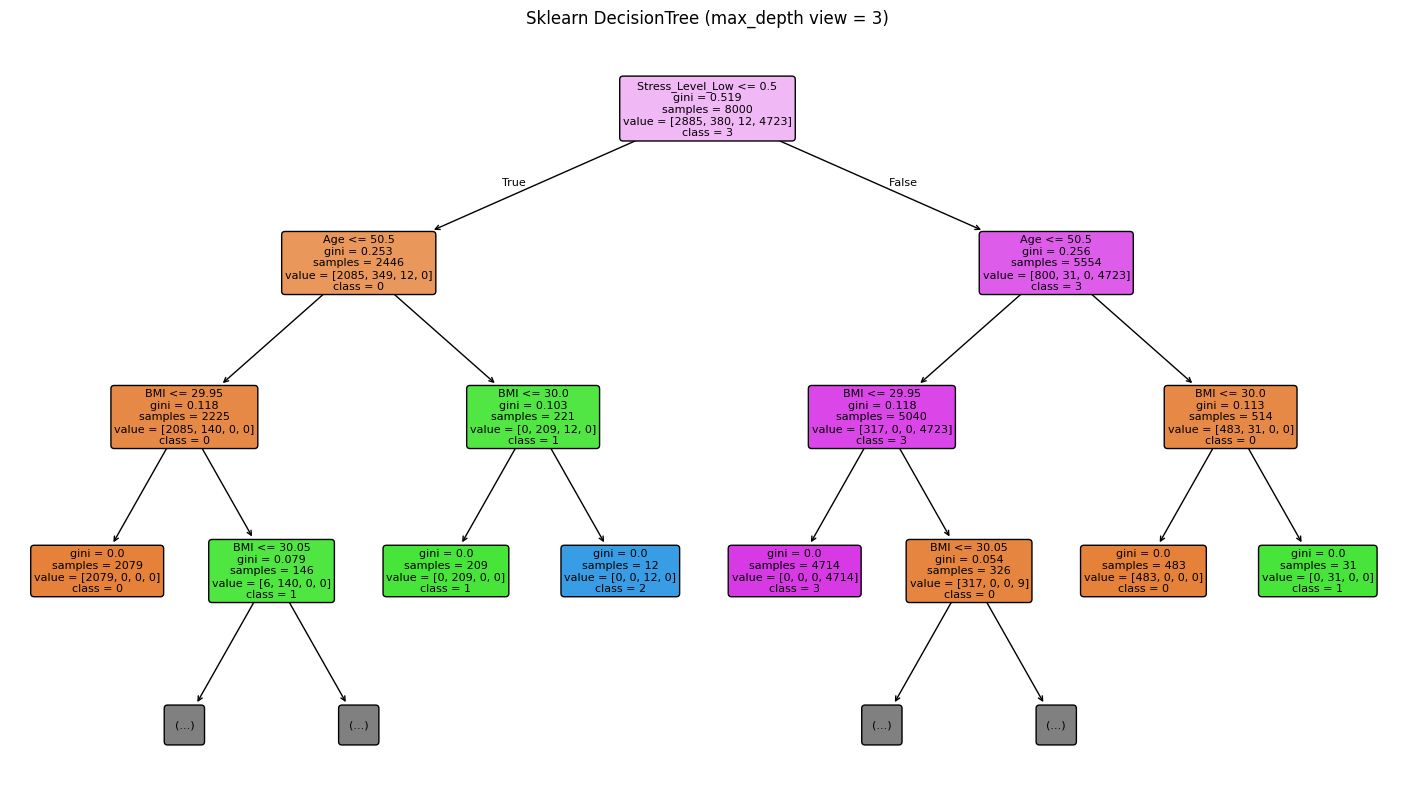

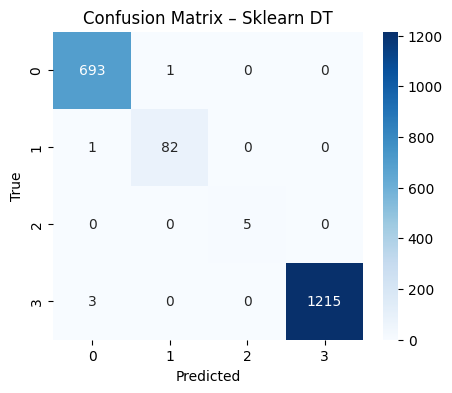

In [99]:
# Sklearn Decision Tree: structure and confusion matrix heatmap
from sklearn.tree import plot_tree

# Ensure we have feature names and class names
feature_names = list(X.columns) if hasattr(X, 'columns') else [f'f{i}' for i in range(X.shape[1])]
class_names = [str(c) for c in np.unique(y)]

# Plot limited-depth view for readability
plt.figure(figsize=(18, 10))
plot_tree(
    dt_sk,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    proportion=False,
    impurity=True,
    max_depth=3,
    fontsize=8
)
plt.title('Sklearn DecisionTree (max_depth view = 3)')
plt.show()

# Confusion matrix heatmap for sklearn DT
from sklearn.metrics import confusion_matrix
cm_sk_viz = confusion_matrix(y_test, dt_sk.predict(X_test))
plt.figure(figsize=(5, 4))
sns.heatmap(cm_sk_viz, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix – Sklearn DT')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


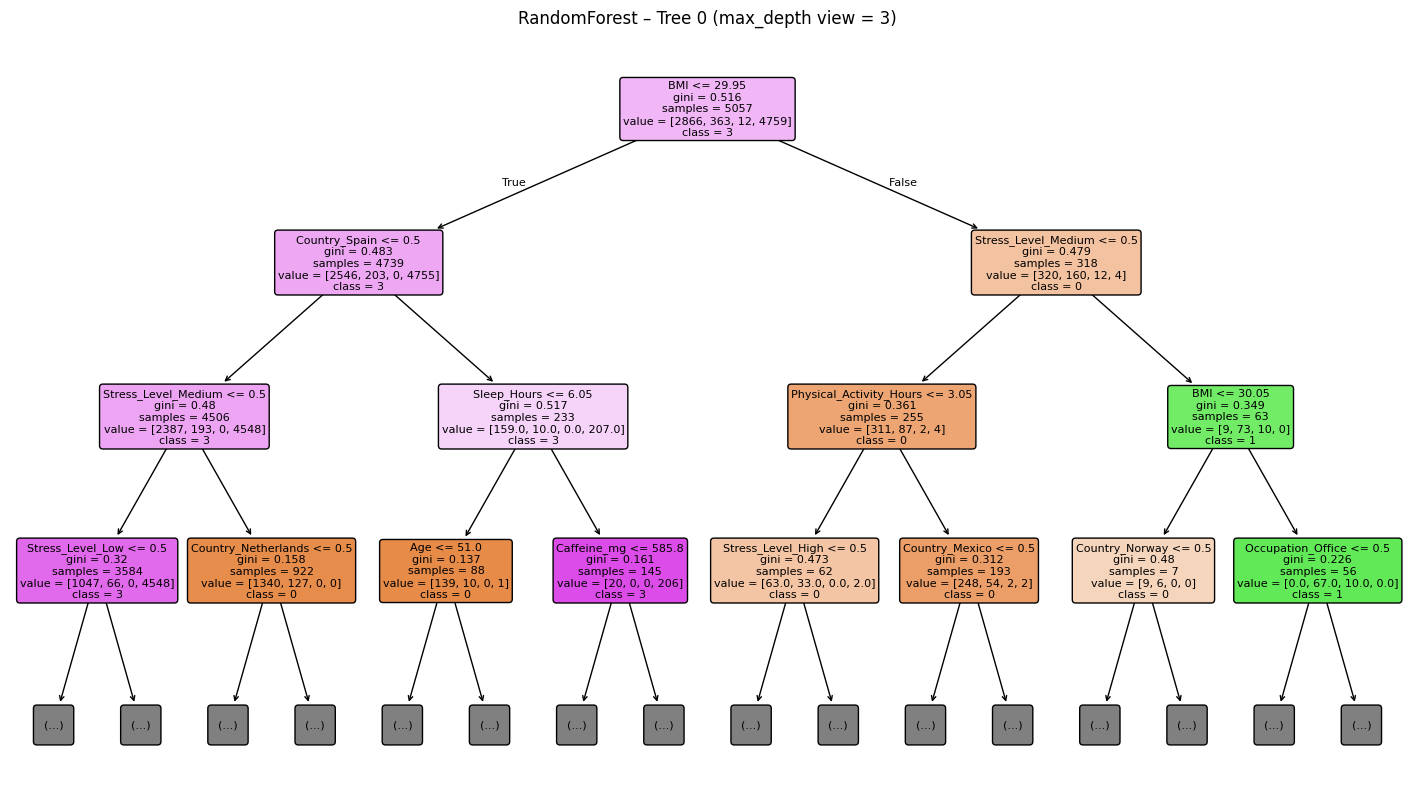

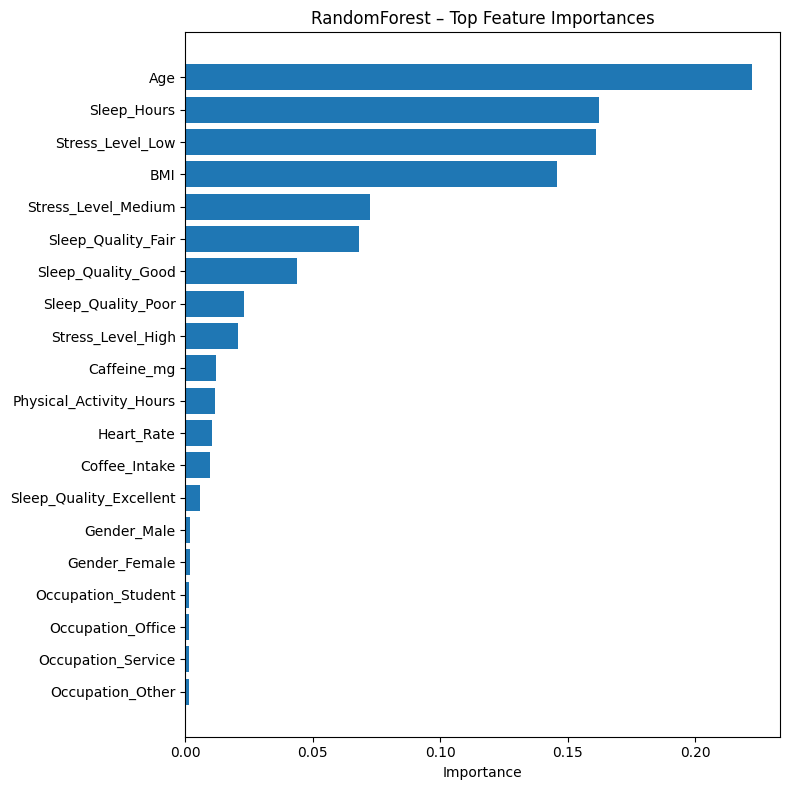

In [100]:
# Random Forest: visualize one tree and feature importances
from sklearn.tree import plot_tree

# Visualize the first tree in the RandomForest for illustration
est0 = rf.estimators_[0]
plt.figure(figsize=(18, 10))
plot_tree(
    est0,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('RandomForest – Tree 0 (max_depth view = 3)')
plt.show()

# Feature importances: top 20 for RF
i_sorted = np.argsort(rf.feature_importances_)[::-1]
num_top = min(20, len(i_sorted))
plt.figure(figsize=(8, max(4, num_top * 0.4)))
plt.barh(range(num_top), rf.feature_importances_[i_sorted[:num_top]][::-1])
plt.yticks(range(num_top), [feature_names[i] for i in i_sorted[:num_top]][::-1])
plt.xlabel('Importance')
plt.title('RandomForest – Top Feature Importances')
plt.tight_layout()
plt.show()


In [101]:
# Print RandomForest feature importances (sorted)
from IPython.display import display

# Build a table of feature importances with names
feature_names_rf = list(X.columns) if hasattr(X, 'columns') else [f"f{i}" for i in range(X.shape[1])]
importances = getattr(rf, "feature_importances_", None)

if importances is None:
    print("RandomForest 'rf' is not fitted yet. Run the training cell first.")
else:
    imp_df = pd.DataFrame({"feature": feature_names_rf, "importance": importances})
    imp_df_sorted = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)

    # Print a concise top-20 list
    print("Top 20 features by importance:")
    for name, val in zip(imp_df_sorted["feature"].head(20), imp_df_sorted["importance"].head(20)):
        print(f"- {name}: {val:.6f}")
    print(f"\nSum of importances: {importances.sum():.6f}")

    # Show a small styled table for a quick scan
    try:
        display(imp_df_sorted.head(30).style.background_gradient(cmap="Blues", subset=["importance"]).format({"importance": "{:.6f}"}))
    except Exception:
        print(imp_df_sorted.head(30).to_string(index=False))


Top 20 features by importance:
- Age: 0.222030
- Sleep_Hours: 0.161992
- Stress_Level_Low: 0.161020
- BMI: 0.145572
- Stress_Level_Medium: 0.072275
- Sleep_Quality_Fair: 0.068122
- Sleep_Quality_Good: 0.043579
- Sleep_Quality_Poor: 0.023188
- Stress_Level_High: 0.020665
- Caffeine_mg: 0.012145
- Physical_Activity_Hours: 0.011795
- Heart_Rate: 0.010321
- Coffee_Intake: 0.009546
- Sleep_Quality_Excellent: 0.005932
- Gender_Male: 0.001680
- Gender_Female: 0.001673
- Occupation_Student: 0.001558
- Occupation_Office: 0.001434
- Occupation_Service: 0.001408
- Occupation_Other: 0.001398

Sum of importances: 1.000000
                feature  importance
                    Age    0.222030
            Sleep_Hours    0.161992
       Stress_Level_Low    0.161020
                    BMI    0.145572
    Stress_Level_Medium    0.072275
     Sleep_Quality_Fair    0.068122
     Sleep_Quality_Good    0.043579
     Sleep_Quality_Poor    0.023188
      Stress_Level_High    0.020665
            Caffeine_mg

In [102]:
# Optional: Simple text visualization of the custom DT (top levels)

def print_tree(node, feature_names, depth=0, max_depth=3):
    indent = '  ' * depth
    if node.get('leaf', False):
        print(f"{indent}Leaf: class={node.get('class')}")
        return
    if depth >= max_depth:
        print(f"{indent}... (depth limit reached)")
        return
    feat = node.get('feature')
    thr = node.get('threshold')
    print(f"{indent}Node: if {feature_names[feat]} <= {thr:.3f}")
    print_tree(node['left'], feature_names, depth+1, max_depth)
    print(f"{indent}else:")
    print_tree(node['right'], feature_names, depth+1, max_depth)

# Use columns from X for names
fn = list(X.columns) if hasattr(X, 'columns') else [f'f{i}' for i in range(X.shape[1])]
print_tree(my_tree.tree, fn, max_depth=3)


Node: if Stress_Level_Low <= 0.500
  Node: if Age <= 50.500
    Node: if BMI <= 29.950
      Leaf: class=0
    else:
      ... (depth limit reached)
  else:
    Node: if BMI <= 30.000
      Leaf: class=1
    else:
      Leaf: class=2
else:
  Node: if Age <= 50.500
    Node: if BMI <= 29.950
      Leaf: class=3
    else:
      ... (depth limit reached)
  else:
    Node: if BMI <= 30.000
      Leaf: class=0
    else:
      Leaf: class=1
